In [1]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 2. download metadata
metadata_path = "UrbanSound8K/metadata/UrbanSound8K.csv"
audio_path = "UrbanSound8K/audio/"

df = pd.read_csv(metadata_path)

print("Original classes from dataset:")
print(df['class'].unique())

Original classes from dataset:
['dog_bark' 'children_playing' 'car_horn' 'air_conditioner' 'street_music'
 'gun_shot' 'siren' 'engine_idling' 'jackhammer' 'drilling']


In [3]:
# 3. Create our classes classters
mapping = {
    "engine_idling": "transport",
    "car_horn": "transport",

    "children_playing": "human",
    "street_music": "human",

    "siren": "alert",

    "drilling": "building_noise",
    "jackhammer": "building_noise"
}

df["new_class"] = df["class"].map(mapping)

df["new_class"] = df["new_class"].fillna("others")

print("\nnew classes:")
print(df["new_class"].value_counts())



new classes:
new_class
others            2374
human             2000
building_noise    2000
transport         1429
alert              929
Name: count, dtype: int64


In [4]:
# 4. Function extract MFCC with padding till 5 seccond
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=5)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print(f"Error with file {file_path}: {e}")
        return None


In [5]:
X = []
y = []

for index, row in df.iterrows():
    file_name = row["slice_file_name"]
    fold = row["fold"]

    file_path = os.path.join(audio_path, f"fold{fold}", file_name)

    features = extract_features(file_path)

    if features is not None:
        X.append(features)
        y.append(row["new_class"])

X = np.array(X)
y = np.array(y)

print("\ndata volume:", X.shape)


C:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(



data volume: (8732, 13)


In [15]:
# 6. normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [16]:
# 7. split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
# 9. Predict
y_pred = model.predict(X_test)

In [19]:
# 10. Accuracy of model CNN
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.8952489982827705

Classification Report:
                precision    recall  f1-score   support

         alert       0.90      0.92      0.91       165
building_noise       0.92      0.92      0.92       414
         human       0.85      0.87      0.86       413
        others       0.88      0.90      0.89       476
     transport       0.95      0.88      0.91       279

      accuracy                           0.90      1747
     macro avg       0.90      0.90      0.90      1747
  weighted avg       0.90      0.90      0.90      1747


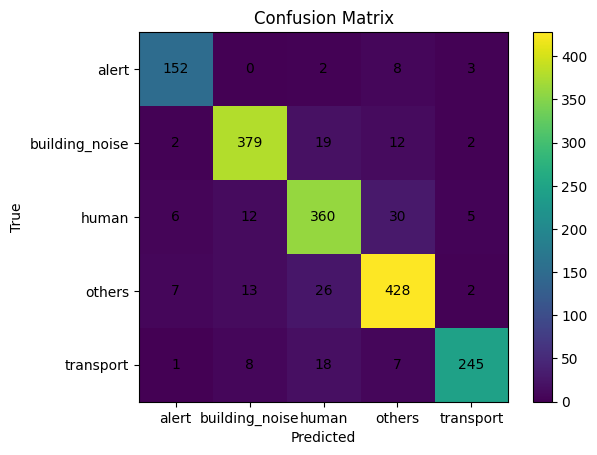

In [20]:
# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = np.unique(y)
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [21]:
# =========================
# 10. Predict custom
# =========================
def extract_features(file_path, max_duration=5):
    try:
        audio, sr = librosa.load(file_path, duration=max_duration)
        if len(audio) < max_duration * sr:
            pad_width = max_duration * sr - len(audio)
            audio = np.pad(audio, (0, pad_width), mode='constant')
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print(f"Error with file {file_path}: {e}")
        return None


def predict_audio_class(file_path, model, scaler):
    features = extract_features(file_path, max_duration=5)
    if features is None:
        return None
    features = scaler.transform([features])
    predicted_class = model.predict(features)[0]
    return predicted_class


user_audio_folder = "UrbanSound8K/Test/user_audio/"

for file_name in os.listdir(user_audio_folder):
    if file_name.endswith(".wav"):
        file_path = os.path.join(user_audio_folder, file_name)
        predicted_class = predict_audio_class(file_path, model, scaler)
        print(f"File {file_name} → class: {predicted_class}")

File auto-volkswagen-engine-at-low-speed-entry-outside.wav → class: transport
File car-won39t-start.wav → class: others
File distant-calm-measured-sound-of-a-running-car-engine.wav → class: transport
File engine-start-and-sound.wav → class: building_noise
File lingering-noisy-sound-of-a-car-engine.wav → class: human
File long-uninterrupted-engine-operation.wav → class: building_noise
File motor-junk.wav → class: others
File old-engine-barely-started.wav → class: human
File powerful-idle-engine.wav → class: others
File smooth-quiet-fast-engine-start.wav → class: others
File sound-when-the-engine-is-turned-off.wav → class: others
File the-car-was-started-and-gassed.wav → class: building_noise
File the-engine-will-not-start.wav → class: human
File uninterrupted-peppy-engine-sound.wav → class: others
File zapusk-dvigatelya-superkar.wav → class: human


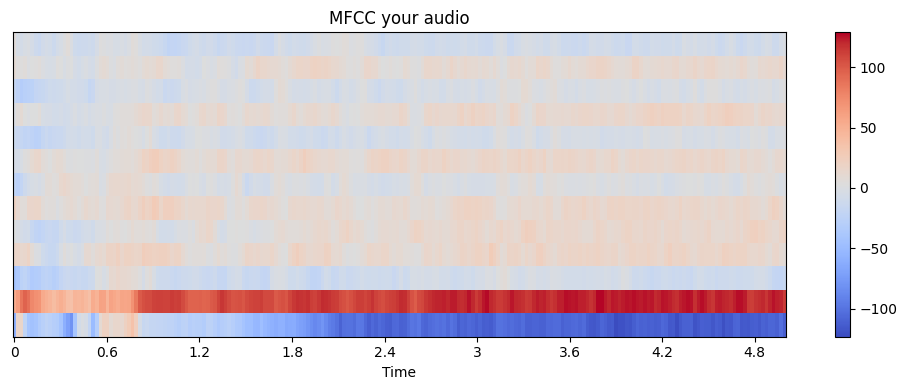

In [22]:
file_path = "UrbanSound8K/Test/user_audio/engine-start-and-sound.wav"
audio, sr = librosa.load(file_path, duration=5)
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title('MFCC your audio')
plt.tight_layout()
plt.show()